In [1]:
# Title

# **1. Configuração Inicial e Aquisição de Dados**

## **1.1. Configuração do Ambiente e Download do Dataset**
Nesta primeira etapa, preparamos o ambiente de desenvolvimento. O objetivo é importar as ferramentas essenciais e garantir o acesso direto ao dataset de radiografias torácicas do National Institutes of Health (NIH), otimizando o processo sem necessidade de downloads manuais pesados.

**Download do Dataset via API do Kaggle**

Utilizamos a biblioteca kagglehub para efetuar o download automático da versão redimensionada (224x224 píxeis) do dataset. Esta abordagem é fundamental para o nosso estudo porque:

  - **Evita o armazenamento local de dezenas de gigabytes.**

  - **Mantém a reprodutibilidade da investigação em qualquer ambiente (como o Google Colab).**

  - **Retorna o caminho absoluto da cache do sistema, permitindo o acesso imediato aos ficheiros e metadados.**

In [2]:
import kagglehub ## Import da biblioteca do Kaggle
path = kagglehub.dataset_download("khanfashee/nih-chest-x-ray-14-224x224-resized") ## Path do dataset

100%|██████████| 2.30G/2.30G [00:19<00:00, 126MB/s]

Extracting files...


#**2. Processamento e Análise de Dados**


## **2.1. Filtragem de Classes e Balanceamento**

Os dados médicos do mundo real apresentam frequentemente um forte desequilíbrio de classes, com uma esmagadora maioria de casos saudáveis face a patologias específicas. Para evitar que o modelo de Deep Learning desenvolva um viés (tendência viciada para prever sempre a classe maioritária), é imperativo isolar as classes de interesse e aplicar técnicas de subamostragem (undersampling).

**Construção do DataFrame Balanceado**

Este bloco de código é o núcleo metodológico da nossa preparação de dados. Ele processa o ficheiro CSV original (Data_Entry_2017.csv) executando as seguintes operações:

  - Mapeamento de Diretórios: Constrói o caminho absoluto para cada imagem física de forma dinâmica.

  - Isolamento da Classe Positiva (Doentes): Filtra exclusivamente os registos radiológicos que contenham as patologias alvo do nosso estudo ("Nodule" ou "Mass").

  - Isolamento da Classe Negativa (Controlo): Seleciona os registos classificados estritamente como "No Finding" (Saudáveis).

  - Undersampling: Reduz aleatoriamente as amostras da classe saudável para igualar o volume exato da classe doente, garantindo um dataset final perfeitamente balanceado (rácio 50/50).

In [7]:
import pandas as pd
import os

print(f"O dataset raiz está guardado em: {path}")

# 1. Encontrar o ficheiro CSV e a pasta real das imagens
csv_path = os.path.join(path, 'Data_Entry_2017.csv')

# --- O TRUQUE PARA ENCONTRAR AS IMAGENS ---
images_folder = path
for root, dirs, files in os.walk(path):
    # Se encontrarmos um ficheiro .png nesta pasta, é aqui que as imagens estão!
    if any(file.endswith('.png') for file in files):
        images_folder = root
        break

print(f"Pasta exata das imagens encontrada em: {images_folder}")

# 2. Ler o ficheiro mestre
df = pd.read_csv(csv_path)

# Criar o caminho completo (Agora com a pasta correta)
df['image_path'] = df['Image Index'].apply(lambda x: os.path.join(images_folder, x))

# -----------------------------------------------------------
# FILTRAGEM E BALANCEAMENTO
# -----------------------------------------------------------
doentes = df[df['Finding Labels'].str.contains("Nodule|Mass", na=False)].copy()
doentes['label'] = 'Doente'

saudaveis = df[df['Finding Labels'] == 'No Finding'].copy()
saudaveis['label'] = 'Saudavel'

saudaveis_balanceado = saudaveis.sample(n=len(doentes), random_state=42)

df_final = pd.concat([doentes, saudaveis_balanceado]).sample(frac=1, random_state=42).reset_index(drop=True)

# -----------------------------------------------------------
# RESULTADOS
# -----------------------------------------------------------
teste_imagem = df_final['image_path'].iloc[0]
print(f"\nCaminho de teste: {teste_imagem}")
print(f"A imagem existe no disco? {os.path.exists(teste_imagem)}")

display(df_final[['Image Index', 'Finding Labels', 'label']].head())

O dataset raiz está guardado em: /root/.cache/kagglehub/datasets/khanfashee/nih-chest-x-ray-14-224x224-resized/versions/3
Pasta exata das imagens encontrada em: /root/.cache/kagglehub/datasets/khanfashee/nih-chest-x-ray-14-224x224-resized/versions/3/images-224/images-224

Caminho de teste: /root/.cache/kagglehub/datasets/khanfashee/nih-chest-x-ray-14-224x224-resized/versions/3/images-224/images-224/00021381_012.png
A imagem existe no disco? True


,Image Index,Finding Labels,label
0,00021381_012.png,Effusion|Emphysema|Infiltration|Nodule,Doente
1,00016358_000.png,Mass,Doente
2,00023033_009.png,No Finding,Saudavel
3,00013104_001.png,Infiltration|Nodule,Doente
4,00005015_006.png,No Finding,Saudavel


# **3. Análise Exploratória de Dados (EDA)**

## **3.1. Validação Visual do Balanceamento e Distribuição**
A Análise Exploratória de Dados é uma fase crucial que nos permite compreender a estrutura do dataset tratado antes de o introduzirmos numa Rede Neuronal. Nesta secção, geramos validações visuais para garantir que o processo de undersampling foi bem-sucedido e que não existe viés de classe (class bias).
Adicionalmente, analisamos algumas das co-ocorrências médicas, visto que um paciente rotulado como "Doente" pode ter Nódulos, Massas, ou ambas as patologias simultaneamente.

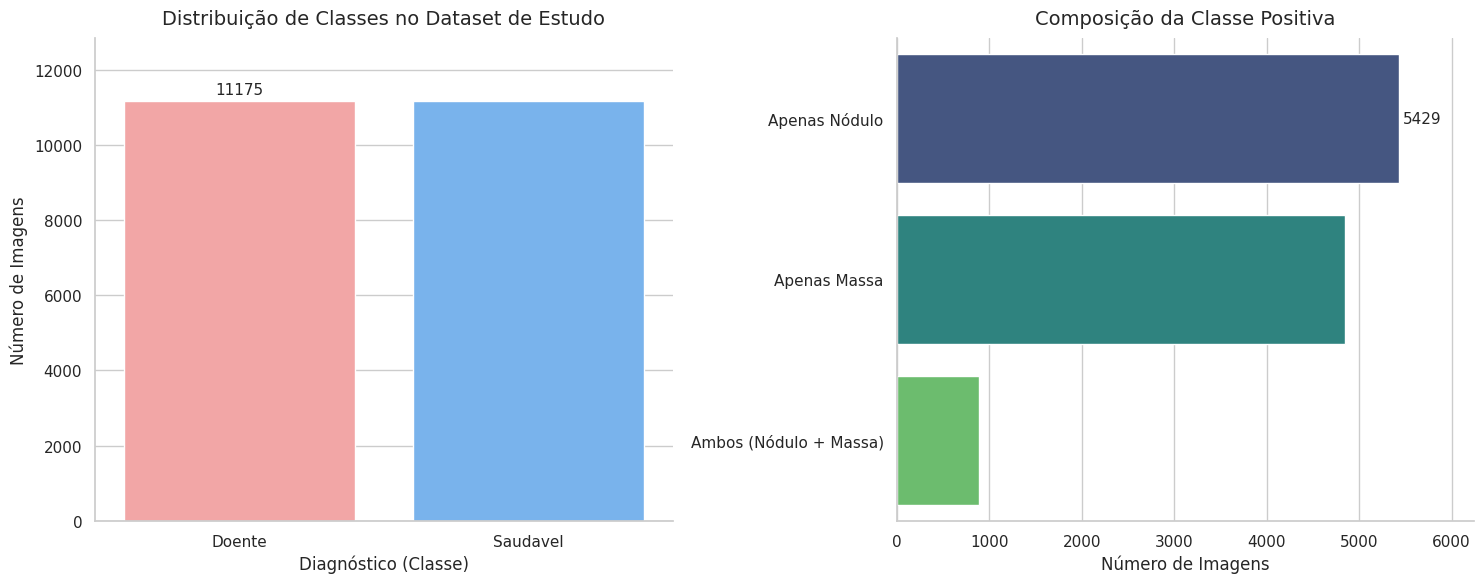

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Criar uma figura com dois gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.set_theme(style="whitegrid")

# --- Gráfico 1: O Balanceamento ---
# CORREÇÃO: hue='label' e legend=False para apagar o aviso vermelho
sns.countplot(data=df_final, x='label', hue='label', palette=['#ff9999', '#66b3ff'], legend=False, ax=axes[0])
axes[0].set_title('Distribuição de Classes no Dataset de Estudo', fontsize=14, pad=10)
axes[0].set_xlabel('Diagnóstico (Classe)', fontsize=12)
axes[0].set_ylabel('Número de Imagens', fontsize=12)

# Dar 15% de margem no topo para os números não baterem no teto
axes[0].margins(y=0.15)
axes[0].bar_label(axes[0].containers[0], padding=3, fontsize=11)

# --- Gráfico 2: Detalhe dos "Doentes" (Nódulos vs Massas) ---
df_doentes = df_final[df_final['label'] == 'Doente'].copy()

def categorizar_patologia(texto):
    if 'Nodule' in texto and 'Mass' in texto: return 'Ambos (Nódulo + Massa)'
    elif 'Nodule' in texto: return 'Apenas Nódulo'
    elif 'Mass' in texto: return 'Apenas Massa'
    return 'Outro'

df_doentes['Tipo'] = df_doentes['Finding Labels'].apply(categorizar_patologia)

# CORREÇÃO: hue='Tipo' e legend=False
sns.countplot(data=df_doentes, y='Tipo', hue='Tipo', palette='viridis', legend=False, ax=axes[1])
axes[1].set_title('Composição da Classe Positiva', fontsize=14, pad=10)
axes[1].set_xlabel('Número de Imagens', fontsize=12)
axes[1].set_ylabel('')

# Dar 15% de margem à direita para os números não cortarem a linha do gráfico
axes[1].margins(x=0.15)
axes[1].bar_label(axes[1].containers[0], padding=3, fontsize=11)

# Limpar as bordas superior e direita do gráfico para um ar mais limpo/moderno
sns.despine()

plt.tight_layout()
plt.show()

# **4. Divisão do Dataset e Exportação**

## **4.1. Train, Validation & Test Split (Estratificação)**

Para treinar um modelo de Deep Learning de forma academicamente rigorosa e evitar o overfitting (quando o modelo decora os dados em vez de aprender as características médicas), precisamos de dividir o nosso dataset em três subconjuntos distintos:

  - Conjunto de Treino (80%): As imagens que o modelo vai ver e usar para ajustar os seus pesos (aprender).

  - Conjunto de Validação (10%): Imagens usadas no final de cada época (ciclo de treino) para avaliar se o modelo está a aprender ou apenas a memorizar. Serve para ajustar hiperparâmetros.

  - Conjunto de Teste (10%): O "exame final". Imagens que o modelo nunca viu durante todo o processo de desenvolvimento. É aqui que tiramos as métricas reais para o relatório (Precisão, Recall, AUC).

---

**Nota Metodológica:** Utilizou-se o parâmetro stratify da biblioteca Scikit-Learn para garantir que a proporção rigorosa de 50/50 (Doente vs Saudável) se mantém intacta dentro de cada um destes três conjuntos. O resultado final é exportado para um ficheiro CSV que servirá de base (a Single Source of Truth) para os notebooks seguintes.






In [10]:
from sklearn.model_selection import train_test_split
from google.colab import files

# 1. Primeira divisão: 80% para Treino, 20% para a reserva (Validação + Teste)
treino, temp = train_test_split(df_final, test_size=0.20, random_state=42, stratify=df_final['label'])

# 2. Segunda divisão: Cortar os 20% da reserva ao meio (10% Validação, 10% Teste)
validacao, teste = train_test_split(temp, test_size=0.50, random_state=42, stratify=temp['label'])

# 3. Marcar na nossa tabela principal a que grupo cada imagem pertence
df_final.loc[treino.index, 'dataset_type'] = 'Treino'
df_final.loc[validacao.index, 'dataset_type'] = 'Validacao'
df_final.loc[teste.index, 'dataset_type'] = 'Teste'

print("--- DISTRIBUIÇÃO DOS CONJUNTOS ---")
print(f"Treino:    {len(treino)} imagens ({len(treino)/len(df_final)*100:.0f}%)")
print(f"Validação: {len(validacao)} imagens ({len(validacao)/len(df_final)*100:.0f}%)")
print(f"Teste:     {len(teste)} imagens ({len(teste)/len(df_final)*100:.0f}%)")

# Confirmar se a estratificação (50/50) funcionou no grupo de Teste
print("\nVerificação de proporção no grupo de Teste:")
print(teste['label'].value_counts())

# 4. Guardar a tabela limpa num ficheiro CSV
nome_ficheiro = 'dataset_processado_final.csv'
df_final.to_csv(nome_ficheiro, index=False)

print(f"\n✅ Ficheiro '{nome_ficheiro}' criado com sucesso!")

# 5. Fazer o download automático para o teu computador
files.download(nome_ficheiro)

--- DISTRIBUIÇÃO DOS CONJUNTOS ---
Treino:    17880 imagens (80%)
Validação: 2235 imagens (10%)
Teste:     2235 imagens (10%)

Verificação de proporção no grupo de Teste:
label
Doente      1118
Saudavel    1117
Name: count, dtype: int64

✅ Ficheiro 'dataset_processado_final.csv' criado com sucesso!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>